In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [45]:
df=pd.read_csv('StudentsPerformance.csv')

In [46]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


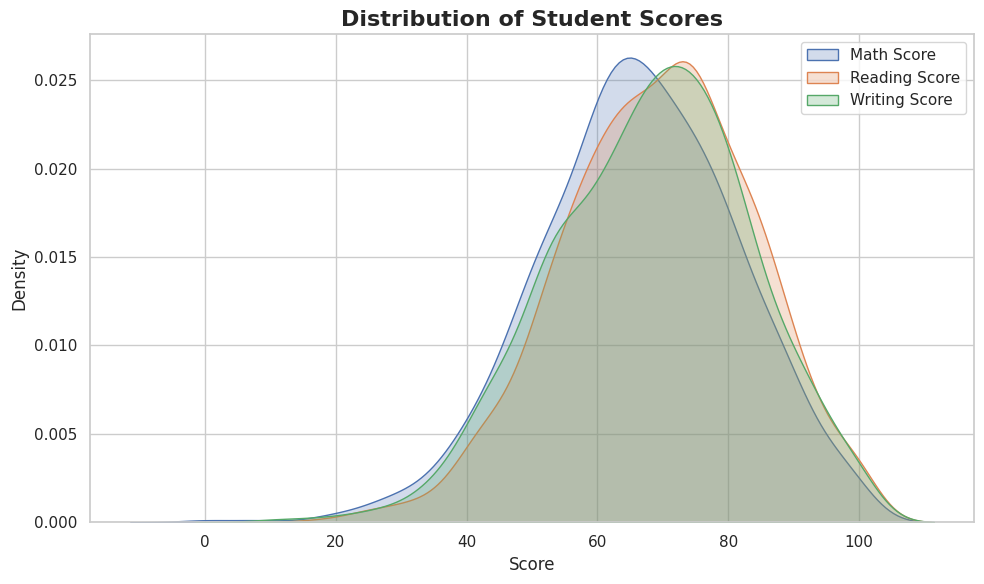

<Figure size 900x600 with 0 Axes>

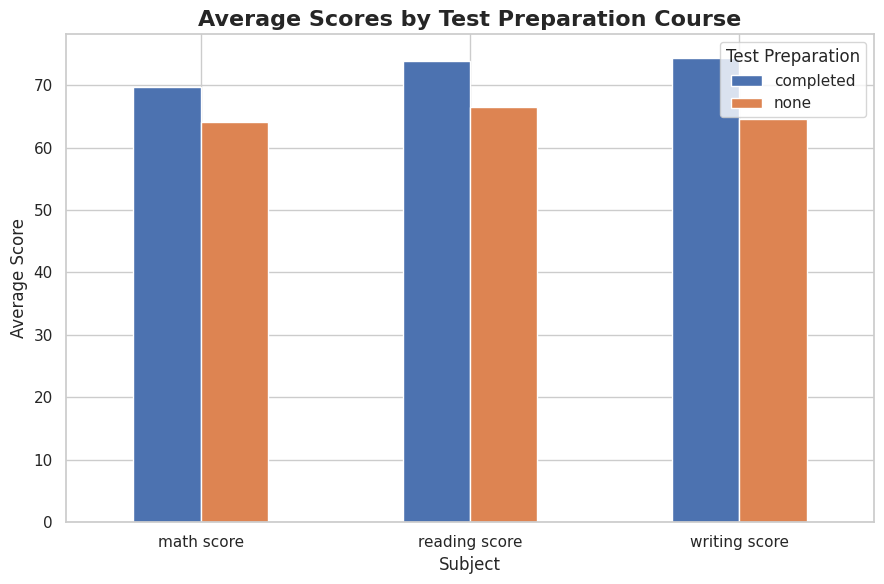

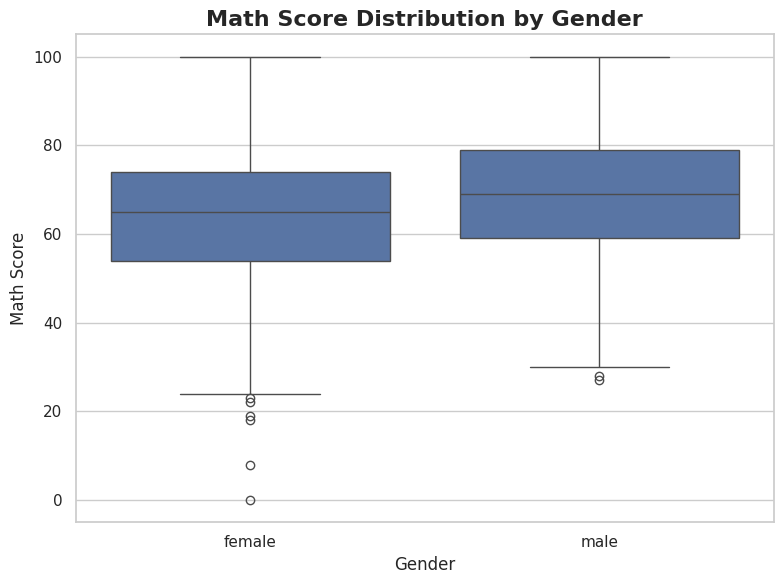

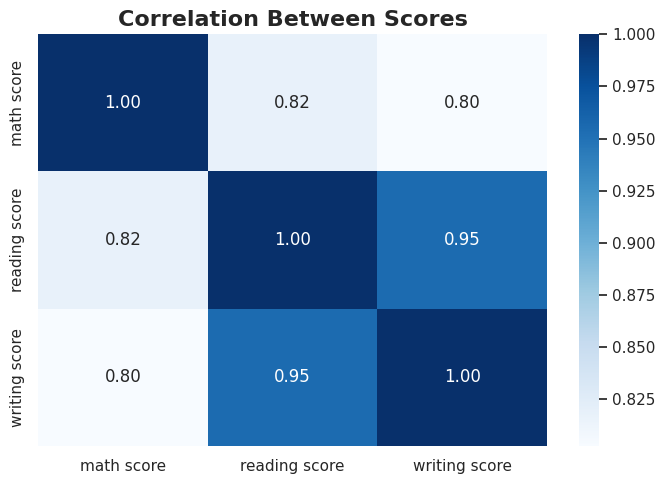

In [47]:
import os
os.makedirs("graph_screenshots", exist_ok=True)

sns.set_theme(style="whitegrid")

# 1) Distribution of scores
plt.figure(figsize=(10,6))
sns.kdeplot(df['math score'], label='Math Score', fill=True)
sns.kdeplot(df['reading score'], label='Reading Score', fill=True)
sns.kdeplot(df['writing score'], label='Writing Score', fill=True)
plt.title("Distribution of Student Scores", fontsize=16, fontweight='bold')
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("graph_screenshots/01_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 2) Average score by test preparation course
score_cols = ['math score', 'reading score', 'writing score']

prep_avg = df.groupby('test preparation course')[score_cols].mean().T

plt.figure(figsize=(9,6))
prep_avg.plot(kind='bar', figsize=(9,6))
plt.title("Average Scores by Test Preparation Course", fontsize=16, fontweight='bold')
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(title="Test Preparation")
plt.tight_layout()
plt.savefig("graph_screenshots/02_test_preparation_impact.png", dpi=300, bbox_inches="tight")
plt.show()

# 3) Math score by gender
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='gender', y='math score')
plt.title("Math Score Distribution by Gender", fontsize=16, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.tight_layout()
plt.savefig("graph_screenshots/03_math_score_by_gender.png", dpi=300, bbox_inches="tight")
plt.show()

# 4) Correlation heatmap of subject scores
plt.figure(figsize=(7,5))
sns.heatmap(df[score_cols].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Between Scores", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("graph_screenshots/04_score_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [49]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [50]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [51]:
df['gender']=df['gender'].map({'male':0,'female':1})

In [52]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,1,group B,bachelor's degree,standard,none,72,72,74
1,1,group C,some college,standard,completed,69,90,88
2,1,group B,master's degree,standard,none,90,95,93
3,0,group A,associate's degree,free/reduced,none,47,57,44
4,0,group C,some college,standard,none,76,78,75


In [53]:
from sklearn.preprocessing import OneHotEncoder

In [54]:
encoder=OneHotEncoder()

In [55]:
encoded=encoder.fit_transform(df[['race/ethnicity']])

In [56]:
encoded_df=pd.DataFrame(
    encoded.toarray(),
    columns=encoder.get_feature_names_out(['race/ethnicity'])
)

In [57]:
df=pd.concat([df,encoded_df],axis=1)

In [58]:
df.drop('race/ethnicity', axis=1, inplace=True)

In [59]:
df.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,1,bachelor's degree,standard,none,72,72,74,0.0,1.0,0.0,0.0,0.0
1,1,some college,standard,completed,69,90,88,0.0,0.0,1.0,0.0,0.0
2,1,master's degree,standard,none,90,95,93,0.0,1.0,0.0,0.0,0.0
3,0,associate's degree,free/reduced,none,47,57,44,1.0,0.0,0.0,0.0,0.0
4,0,some college,standard,none,76,78,75,0.0,0.0,1.0,0.0,0.0


In [60]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [61]:
# Create ranking dictionary
education_order = {
    'some high school': 0,
    'high school': 1,
    'some college': 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}

# Replace text with numerical ranking
df['parental level of education'] = df['parental level of education'].map(education_order)

In [62]:
df.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,1,4,standard,none,72,72,74,0.0,1.0,0.0,0.0,0.0
1,1,2,standard,completed,69,90,88,0.0,0.0,1.0,0.0,0.0
2,1,5,standard,none,90,95,93,0.0,1.0,0.0,0.0,0.0
3,0,3,free/reduced,none,47,57,44,1.0,0.0,0.0,0.0,0.0
4,0,2,standard,none,76,78,75,0.0,0.0,1.0,0.0,0.0


In [63]:
df['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

In [64]:
df['lunch']=df['lunch'].map({'standard':0,'free/reduced':1})

In [65]:
df.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,1,4,0,none,72,72,74,0.0,1.0,0.0,0.0,0.0
1,1,2,0,completed,69,90,88,0.0,0.0,1.0,0.0,0.0
2,1,5,0,none,90,95,93,0.0,1.0,0.0,0.0,0.0
3,0,3,1,none,47,57,44,1.0,0.0,0.0,0.0,0.0
4,0,2,0,none,76,78,75,0.0,0.0,1.0,0.0,0.0


In [66]:
df['lunch'].unique()

array([0, 1])

In [67]:
df['lunch'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: lunch
Non-Null Count  Dtype
--------------  -----
1000 non-null   int64
dtypes: int64(1)
memory usage: 7.9 KB


In [68]:
df['parental level of education'].isnull().sum()

np.int64(0)

In [69]:
df['test preparation course'].unique()

array(['none', 'completed'], dtype=object)

In [70]:
df['test preparation course']=df['test preparation course'].map({'none':0,'completed':1})

In [71]:
df.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,1,4,0,0,72,72,74,0.0,1.0,0.0,0.0,0.0
1,1,2,0,1,69,90,88,0.0,0.0,1.0,0.0,0.0
2,1,5,0,0,90,95,93,0.0,1.0,0.0,0.0,0.0
3,0,3,1,0,47,57,44,1.0,0.0,0.0,0.0,0.0
4,0,2,0,0,76,78,75,0.0,0.0,1.0,0.0,0.0


In [72]:
df['test preparation course'].isnull().sum()

np.int64(0)

In [73]:
X=df.drop('math score',axis=1)
y=df['math score']

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [76]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


In [77]:
lr=LinearRegression()
ridge=Ridge()
lasso=Lasso()

In [78]:
lr.fit(X_train,y_train)
ridge.fit(X_train,y_train)
lasso.fit(X_train,y_train)

Lasso()

In [79]:
lr_pred = lr.predict(X_test)
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

,Model,R2 Score,MAE,MSE
0,Linear Regression,0.881560,4.181966,28.821057
1,Ridge,0.881680,4.181345,28.791815
2,Lasso,0.856434,4.628667,34.935079


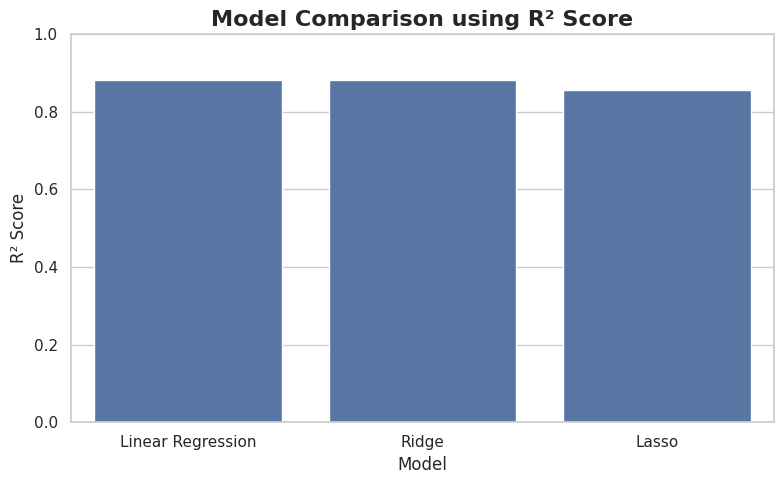

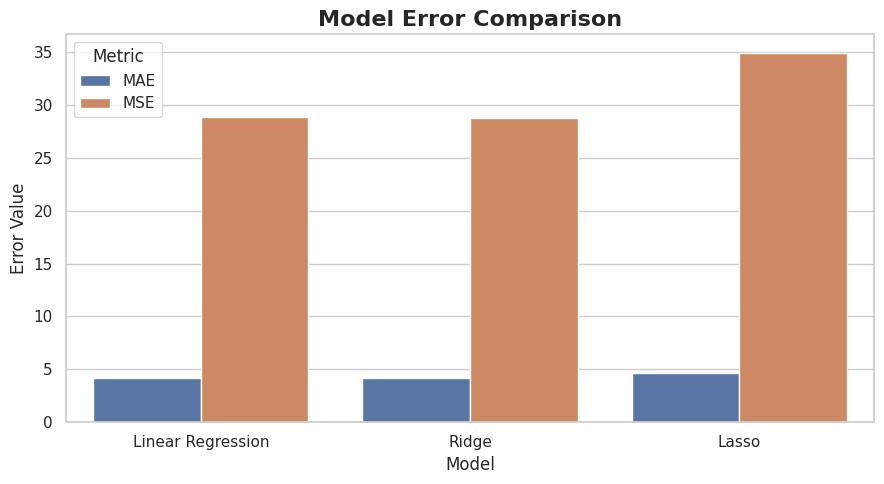

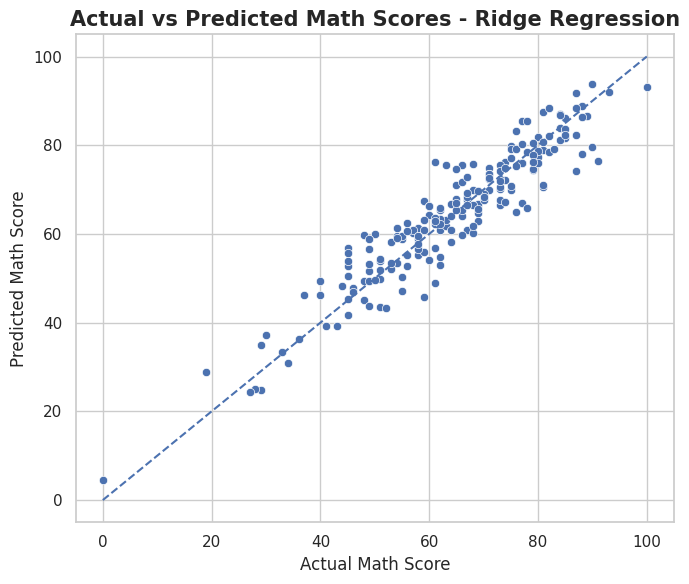

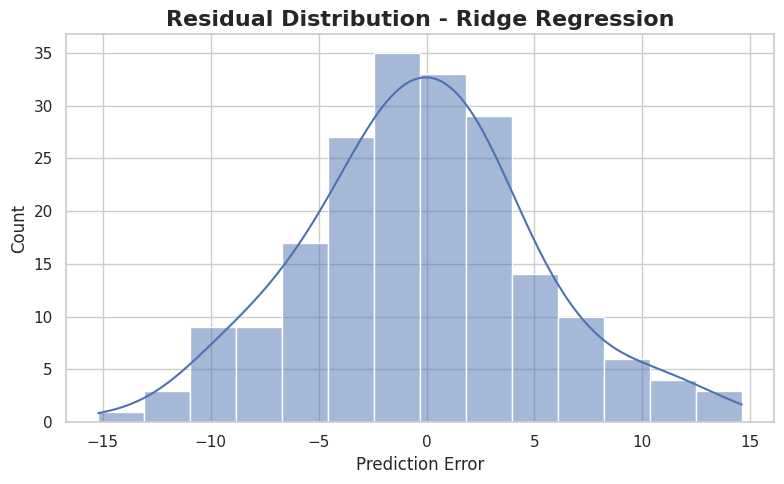

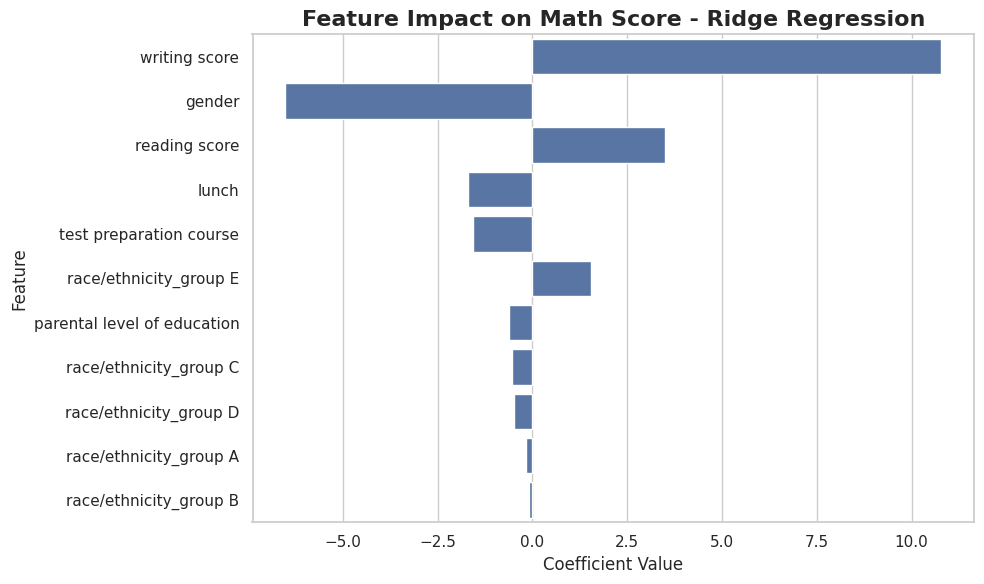

In [80]:
import os
os.makedirs("graph_screenshots", exist_ok=True)

model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],
    "MSE": [
        mean_squared_error(y_test, lr_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred)
    ]
})

display(model_results)

# 5) R2 Score comparison
plt.figure(figsize=(8,5))
sns.barplot(data=model_results, x="Model", y="R2 Score")
plt.title("Model Comparison using R² Score", fontsize=16, fontweight='bold')
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("graph_screenshots/05_model_r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 6) Error comparison: MAE and MSE
error_df = model_results.melt(
    id_vars="Model",
    value_vars=["MAE", "MSE"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(9,5))
sns.barplot(data=error_df, x="Model", y="Value", hue="Metric")
plt.title("Model Error Comparison", fontsize=16, fontweight='bold')
plt.xlabel("Model")
plt.ylabel("Error Value")
plt.tight_layout()
plt.savefig("graph_screenshots/06_model_error_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 7) Actual vs predicted values for Ridge model
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=ridge_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Actual vs Predicted Math Scores - Ridge Regression", fontsize=15, fontweight='bold')
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.tight_layout()
plt.savefig("graph_screenshots/07_actual_vs_predicted_ridge.png", dpi=300, bbox_inches="tight")
plt.show()

# 8) Residual distribution for Ridge model
residuals = y_test - ridge_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution - Ridge Regression", fontsize=16, fontweight='bold')
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("graph_screenshots/08_residual_distribution_ridge.png", dpi=300, bbox_inches="tight")
plt.show()

# 9) Feature importance using Ridge coefficients
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x="Coefficient", y="Feature")
plt.title("Feature Impact on Math Score - Ridge Regression", fontsize=16, fontweight='bold')
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("graph_screenshots/09_feature_impact_ridge.png", dpi=300, bbox_inches="tight")
plt.show()


In [81]:
print("Linear Regression")
print("R2 Score:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))

Linear Regression
R2 Score: 0.8815597679452445
MAE: 4.1819664183215135
MSE: 28.821056563832908


In [82]:
print("Ridge")
print("R2 Score:", r2_score(y_test, ridge_pred))
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("MSE:", mean_squared_error(y_test, ridge_pred))

Ridge
R2 Score: 0.8816799346594386
MAE: 4.181345124888821
MSE: 28.791815387867654


In [83]:
print("Lasso")
print("R2 Score:", r2_score(y_test, lasso_pred))
print("MAE:", mean_absolute_error(y_test, lasso_pred))
print("MSE:", mean_squared_error(y_test, lasso_pred))

Lasso
R2 Score: 0.8564341701037732
MAE: 4.628666629691969
MSE: 34.93507934161998


In [84]:
import pickle

pickle.dump(ridge, open('model.pkl', 'wb'))

In [85]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [86]:
import os
os.listdir()

['.config',
 'scaler.pkl',
 'graph_screenshots',
 'StudentsPerformance.csv',
 'model.pkl',
 'sample_data']